In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error

In [3]:
gold=pd.read_csv(r"G:\Ddrive\PG DBDA\12 Practical Machine Learning_\dayWise\1. Supervised\15. Time Series Analysis\gold.csv")
gold.head()

,Year,Price
0,1964,63.25
1,1965,71.75
2,1966,83.75
3,1967,102.50
4,1968,162.00


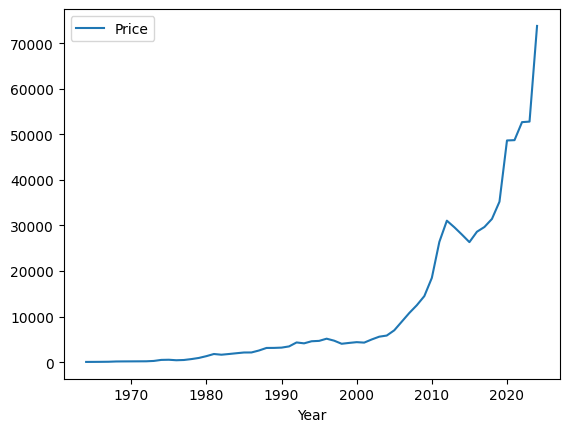

In [4]:
gold.plot.line(x = 'Year',y = 'Price')
plt.show()

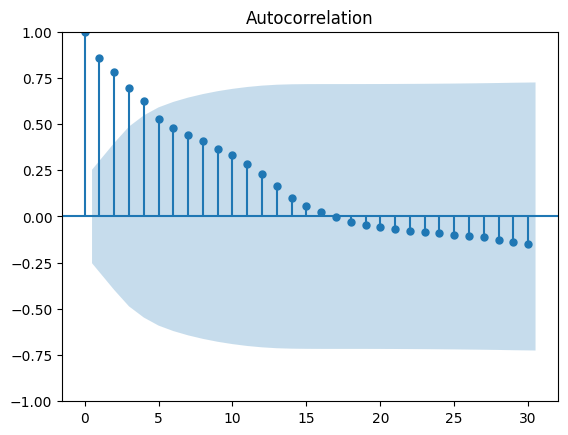

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(gold['Price'], lags=30)
plt.show()

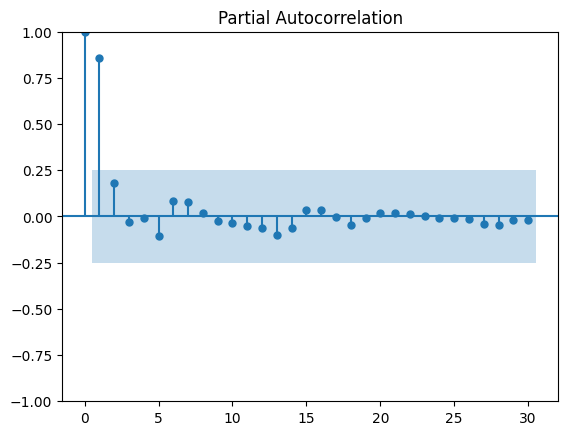

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(gold['Price'], lags=30)
plt.show()

In [7]:
gold.shape

(60, 2)

In [8]:
y = gold['Price']
y_train = y[:-5]
y_test = y[-5:]
y_train.shape

(55,)

In [25]:
y_train.tail()

50    26343.5
51    28623.5
52    29667.5
53    31438.0
54    35220.0
Name: Price, dtype: float64

In [24]:
y_test.shape

(5,)

In [26]:
y_test.tail()

55    48651.0
56    48720.0
57    52670.0
58    52790.0
59    73780.0
Name: Price, dtype: float64

In [20]:
########################## AR ##############################
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(y_train,lags=7).fit()
#model_fit = model.fit(maxlag=12)
#print('Lag: %s' % model._k_ar)
#print('Coefficients: %s' % model.params)
# make predictions
predictions = model.predict(start=len(y_train), 
                                end=len(y_train)+len(y_test)-1, 
                                dynamic=False)
    
error = mean_squared_error(y_test, predictions)
print('Test RMSE: %.3f' % sqrt(error))

Test RMSE: 6277.669


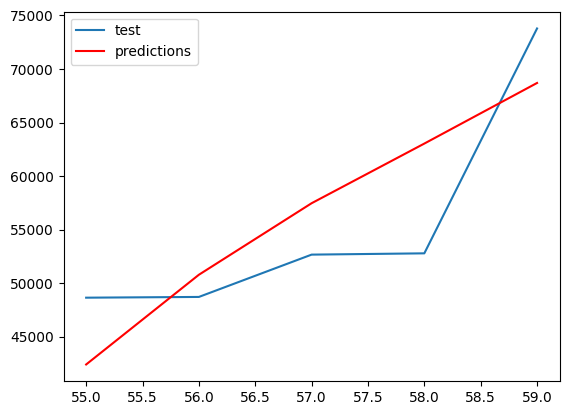

In [21]:
# plot results
plt.plot(y_test,label ="test")
plt.plot(predictions, color='red',label ="predictions")
plt.legend(loc='best')
plt.show()

Test RMSE: 6277.669


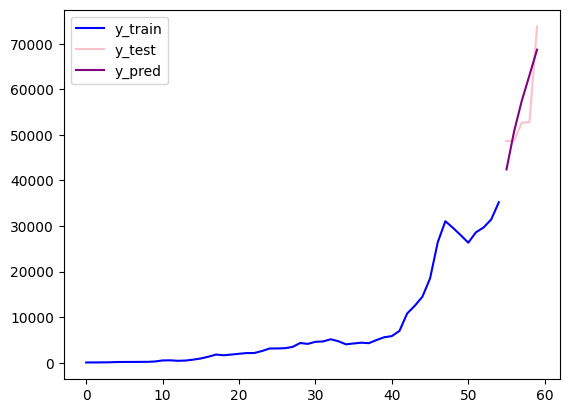

In [30]:
# plot
#y.plot(color="black",label ="y" )
y_train.plot(color="blue",label ="y_train")
y_test.plot(color="pink",label ="y_test")
predictions.plot(color="purple",label ="y_pred")
plt.legend(loc='best')

rms = sqrt(mean_squared_error(y_test, predictions))
print('Test RMSE: %.3f' % rms)

In [32]:
################# ARIMA ####################################

from statsmodels.tsa.arima.model import ARIMA

# train ARIMA
model = ARIMA(y_train,order=(3,1,0))
model_fit = model.fit()
#print('Lag: %s' % model_fit._k_ar)
print('Coefficients: %s' % model_fit.params)
# make predictions
predictions = model_fit.predict(start=len(y_train), 
                                end=len(y_train)+len(y_test)-1, 
                                dynamic=False)
    
error = mean_squared_error(y_test, predictions)
print('Test RMSE: %.3f' % sqrt(error))

Coefficients: ar.L1     8.820208e-01
ar.L2    -3.896819e-01
ar.L3     1.597645e-01
sigma2    1.643884e+06
dtype: float64
Test RMSE: 17861.920


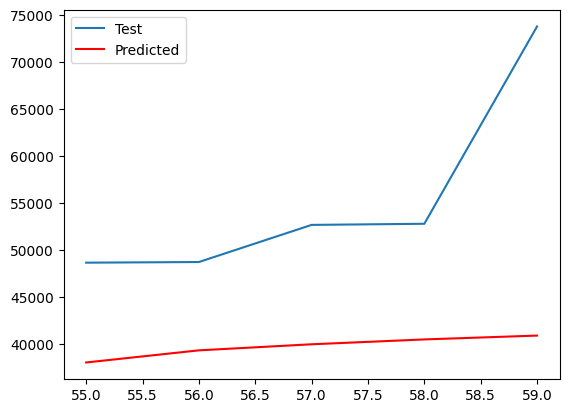

In [33]:
# plot results
plt.plot(y_test,label='Test')
plt.plot(predictions,label='Predicted', color='red')
plt.legend(loc = 'best')
plt.show()

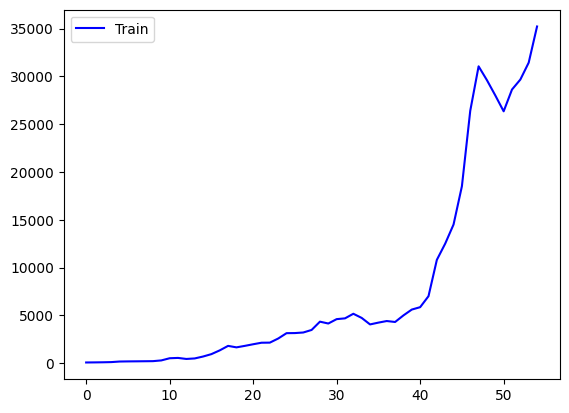

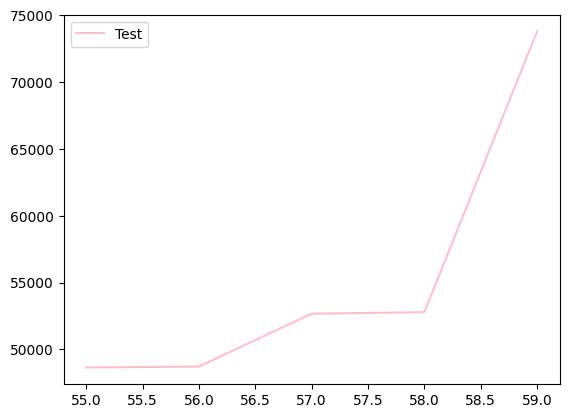

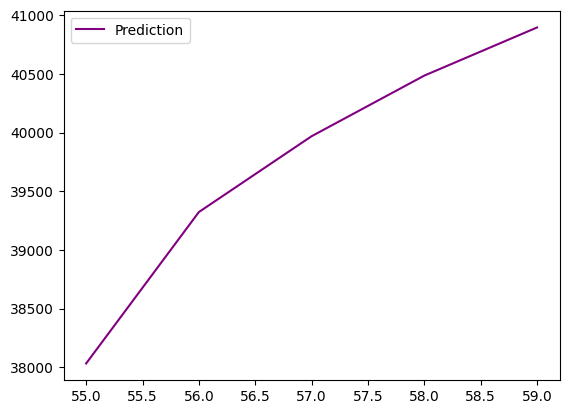

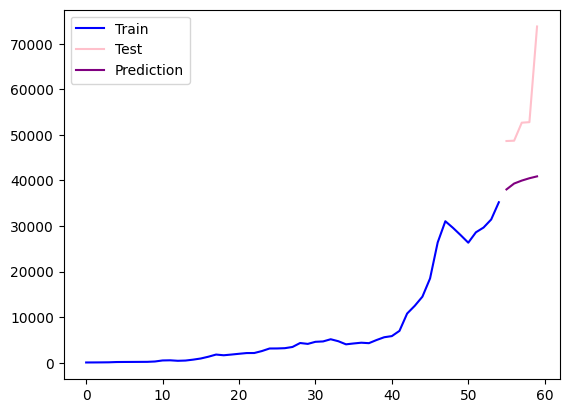

Test RMSE: 17861.920


In [34]:
# plot
y_train.plot(label='Train',color="blue")
plt.legend(loc = 'best')
plt.show()

y_test.plot(label='Test',color="pink")
plt.legend(loc = 'best')
plt.show()

predictions.plot(label='Prediction',color="purple")
plt.legend(loc = 'best')
plt.show()

y_train.plot(label='Train',color="blue")
y_test.plot(label='Test',color="pink")
predictions.plot(label='Prediction',color="purple")
plt.legend(loc = 'best')
plt.show()

rms = sqrt(mean_squared_error(y_test, predictions))
print('Test RMSE: %.3f' % rms)

In [36]:
######################## auto_arima #####################################
from pmdarima.arima import auto_arima
model = auto_arima(y_train, trace=True,
                   error_action='ignore', 
                   suppress_warnings=True)

forecast = model.predict(n_periods=len(y_test))
forecast = pd.DataFrame(forecast,index = y_test.index,
                        columns=['Prediction'])

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=920.457, Time=0.40 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=921.816, Time=0.05 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=923.696, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=923.664, Time=0.10 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=914.447, Time=0.76 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=913.999, Time=0.37 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=inf, Time=0.79 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=917.326, Time=0.43 sec
 ARIMA(1,2,3)(0,0,0)[0]             : AIC=inf, Time=0.85 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.52 sec

Best model:  ARIMA(0,2,2)(0,0,0)[0]          
Total fit time: 4.371 seconds


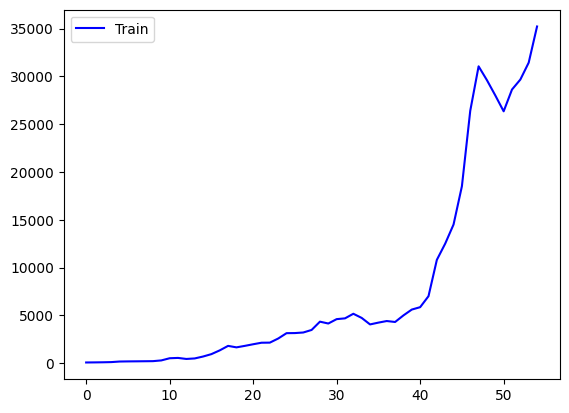

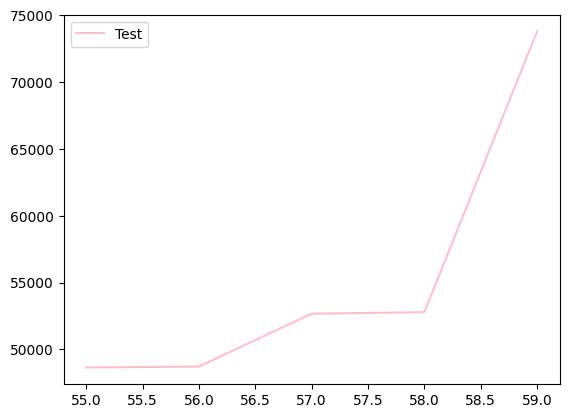

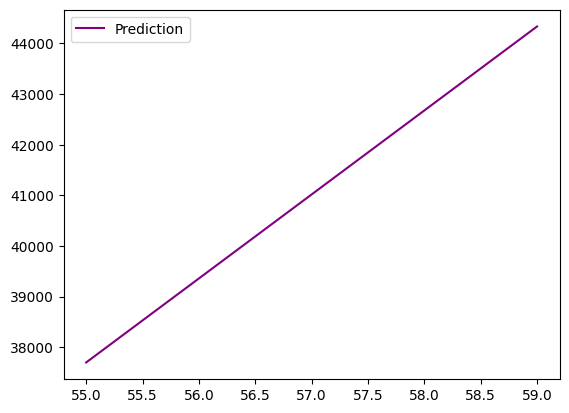

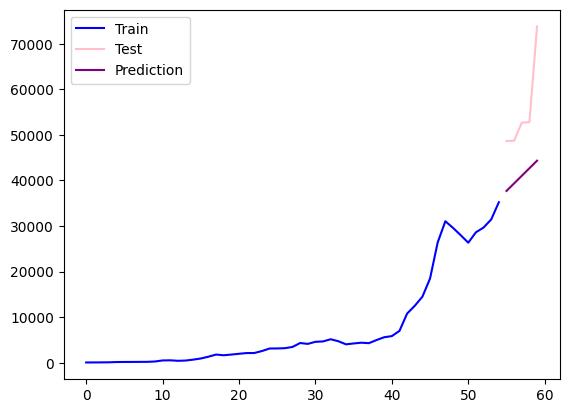

In [37]:
#plot the predictions for validation set
plt.plot(y_train, label='Train',color="blue")
plt.legend(loc = 'best')
plt.show()
plt.plot(y_test, label='Test',color="pink")
plt.legend(loc = 'best')
plt.show()
plt.plot(forecast, label='Prediction',color="purple")
plt.legend(loc = 'best')
plt.show()
plt.plot(y_train, label='Train',color="blue")
plt.plot(y_test, label='Test',color="pink")
plt.plot(forecast, label='Prediction',color="purple")
plt.legend(loc = 'best')
plt.show()

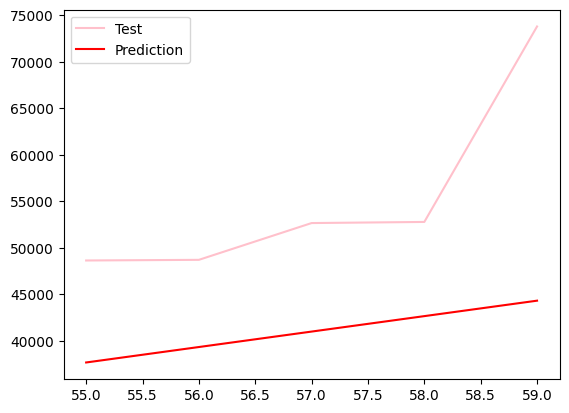

Test RMSE: 16202.941


In [38]:
# plot results
plt.plot(y_test, label='Test',color="pink")
plt.plot(forecast, label='Prediction',color='red')
plt.legend(loc = 'best')
plt.show()

rms = sqrt(mean_squared_error(y_test, forecast))
print('Test RMSE: %.3f' % rms)

In [39]:
### SARMIA
model = auto_arima(y_train, trace=True, 
                   error_action='ignore', 
                   suppress_warnings=True,seasonal=True,m=12)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[12]             : AIC=924.098, Time=2.27 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=921.816, Time=0.05 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=925.636, Time=0.16 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=925.375, Time=0.43 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=923.762, Time=0.27 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=923.743, Time=0.49 sec
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=inf, Time=0.77 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=923.696, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=923.664, Time=0.10 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=917.326, Time=0.44 sec
 ARIMA(1,2,1)(1,0,0)[12]             : AIC=918.934, Time=1.07 sec
 ARIMA(1,2,1)(0,0,1)[12]             : AIC=918.863, Time=0.82 sec
 ARIMA(1,2,1)(1,0,1)[12]             : AIC=920.811, Time=1.01 sec
 ARIMA(2,2,1)(0,0,0)[12]             : AIC=912.774, Time=0.34 sec
 ARIMA(2,2,1)(1,0,0)[12]             

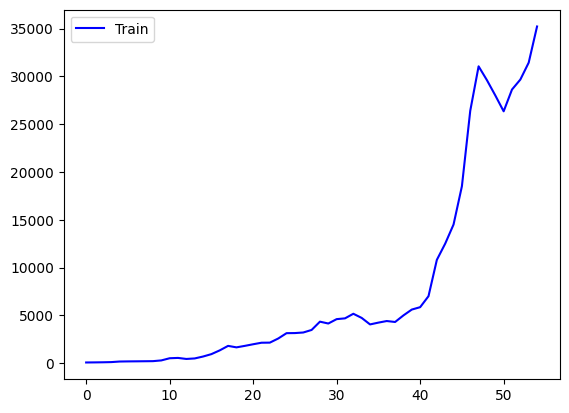

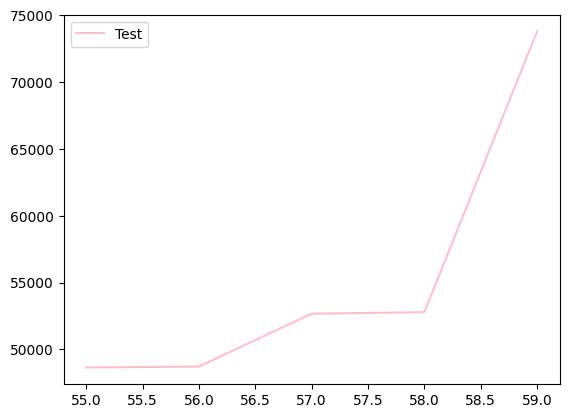

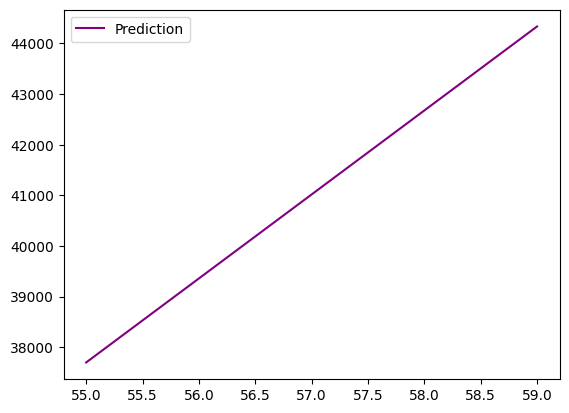

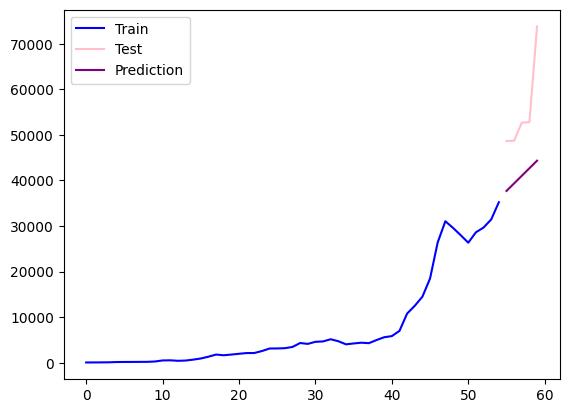

In [40]:
#plot the predictions for validation set
plt.plot(y_train, label='Train',color="blue")
plt.legend(loc = 'best')
plt.show()
plt.plot(y_test, label='Test',color="pink")
plt.legend(loc = 'best')
plt.show()
plt.plot(forecast, label='Prediction',color="purple")
plt.legend(loc = 'best')
plt.show()
plt.plot(y_train, label='Train',color="blue")
plt.plot(y_test, label='Test',color="pink")
plt.plot(forecast, label='Prediction',color="purple")
plt.legend(loc = 'best')
plt.show()

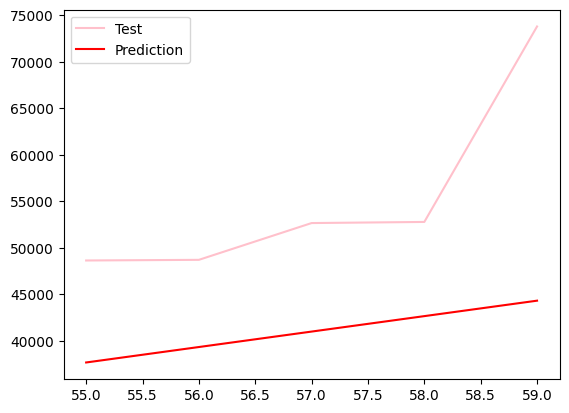

Test RMSE: 16202.941


In [41]:
# plot results
plt.plot(y_test, label='Test',color="pink")
plt.plot(forecast, label='Prediction',color='red')
plt.legend(loc = 'best')
plt.show()

rms = sqrt(mean_squared_error(y_test, forecast))
print('Test RMSE: %.3f' % rms)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=1105.208, Time=0.69 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=1123.226, Time=0.03 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=1113.520, Time=0.07 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=1107.249, Time=0.18 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=1103.921, Time=0.84 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=1108.983, Time=0.28 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=1106.558, Time=0.31 sec
 ARIMA(1,2,3)(0,0,0)[0]             : AIC=1086.622, Time=0.63 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=inf, Time=0.70 sec
 ARIMA(2,2,3)(0,0,0)[0]             : AIC=1092.317, Time=1.03 sec
 ARIMA(1,2,4)(0,0,0)[0]             : AIC=1087.730, Time=1.18 sec
 ARIMA(0,2,4)(0,0,0)[0]             : AIC=inf, Time=0.85 sec
 ARIMA(2,2,4)(0,0,0)[0]             : AIC=1101.800, Time=1.37 sec
 ARIMA(1,2,3)(0,0,0)[0] intercept   : AIC=1086.109, Time=1.02 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=1

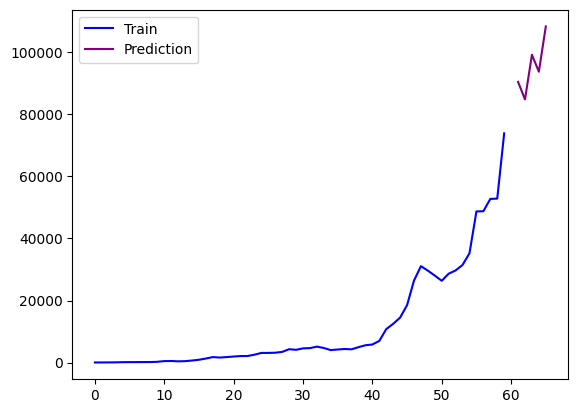

In [43]:
################# Next 6 Months Prediction ##############
#### Building model on the whole data
model = auto_arima(y, trace=True, error_action='ignore', 
                   suppress_warnings=True)   

import numpy as np
forecast = model.predict(n_periods=6)
forecast = pd.DataFrame(forecast,index = np.arange(y.shape[0]+1,y.shape[0]+7),
                        columns=['Prediction'])

#plot the predictions for validation set
plt.plot(y, label='Train',color="blue")
plt.plot(forecast, label='Prediction',color="purple")
plt.legend(loc='best')
plt.show()

In [44]:
print(forecast)

       Prediction
61   90332.477171
62   84695.751233
63   99062.717126
64   93605.351871
65  108151.678408
66            NaN


##  Smoothing  ##
###  Moving Averge  ###

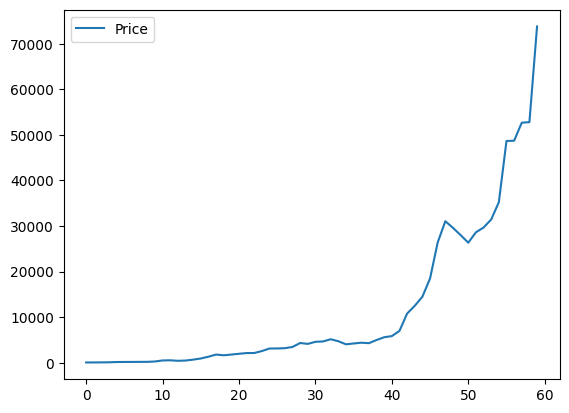

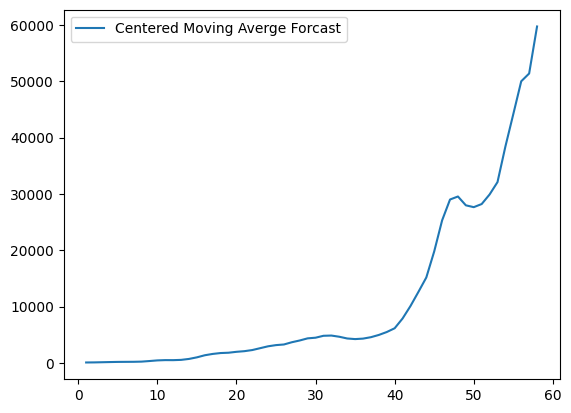

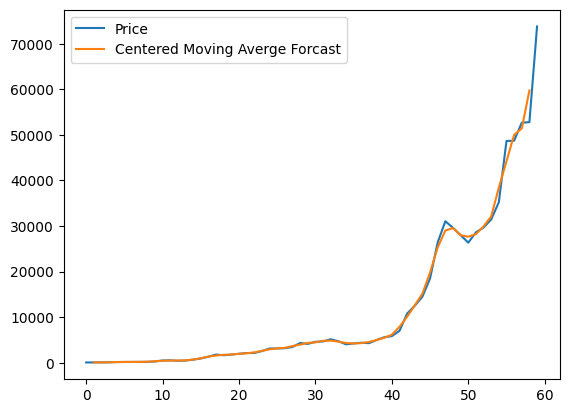

In [46]:
############ Centered Moving Averge ########## for Visualization 
fcast=y.rolling(3,center=True).mean()
#MA is calculated using df.rolling()
plt.plot(y,label='Price')
plt.legend(loc='best')
plt.show()

plt.plot(fcast,label='Centered Moving Averge Forcast')
plt.legend(loc='best')
plt.show()

plt.plot(y,label='Price')
plt.plot(fcast,label='Centered Moving Averge Forcast')
plt.legend(loc='best')
plt.show()

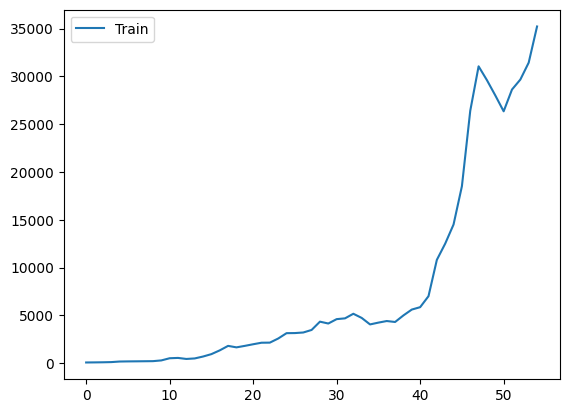

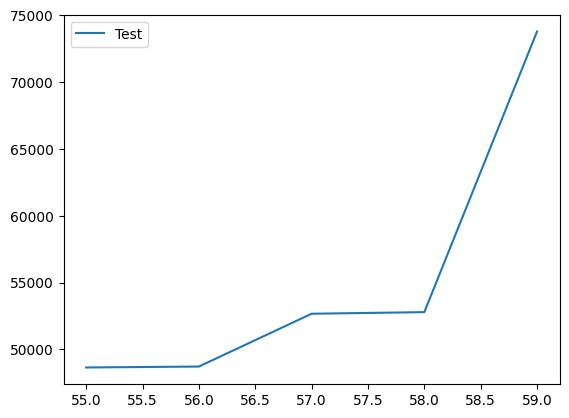

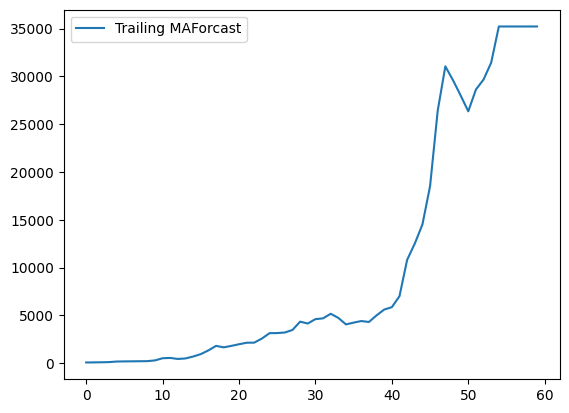

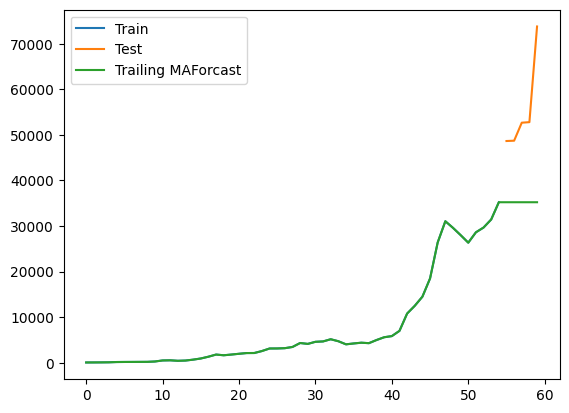

Moving Averge: 35220.0


In [65]:
############ Trailing Moving Averge ########## for Forcasting
#y_train = y[:156]
#y_test = y[156:]
span = 1
fcast=y_train.rolling(span).mean()
MA = fcast.iloc[-1]
MA_series= pd.Series(MA.repeat(len(y_test)))
MA_Fcast = pd.concat([fcast,MA_series],ignore_index=True)

plt.plot(y_train,label='Train')
plt.legend(loc='best')
plt.show()

plt.plot(y_test,label='Test')
plt.legend(loc='best')
plt.show()

plt.plot(MA_Fcast,label="Trailing MAForcast")
plt.legend(loc='best')
plt.show()

plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.plot(MA_Fcast,label="Trailing MAForcast")
plt.legend(loc='best')
plt.show()
print(f'Moving Averge: {MA}')

In [66]:
rms=sqrt(mean_squared_error(y_test, MA_series))
print(f'RMS: {rms}')

RMS: 22193.344772701566


In [64]:
############ Trailing Moving Averge ########## for Forcasting
span = list(range(1,11))
for i in span:
    print(f'RMS Error Span {i}: {sqrt(mean_squared_error(y_test,y_train.rolling(i).mean().iloc[-1].repeat(len(y_test))))}')

RMS Error Span 1: 22193.344772701566
RMS Error Span 2: 23919.593508251764
RMS Error Span 3: 25046.396448391533
RMS Error Span 4: 25855.964957094522
RMS Error Span 5: 26770.04230571928
RMS Error Span 6: 27121.77214516862
RMS Error Span 7: 27159.7183274144
RMS Error Span 8: 27018.19421964808
RMS Error Span 9: 27392.868242989414
RMS Error Span 10: 28437.418635487993


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


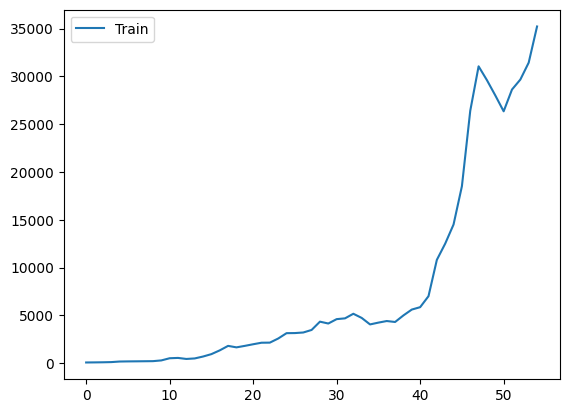

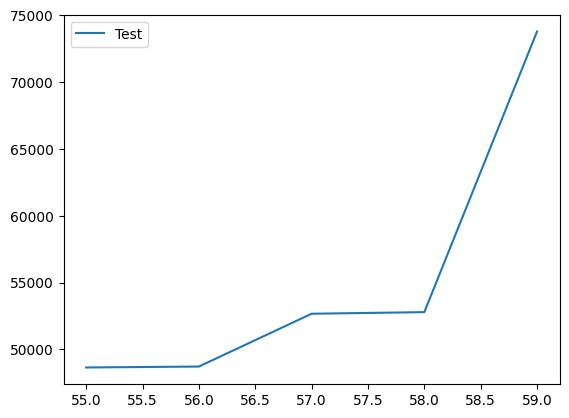

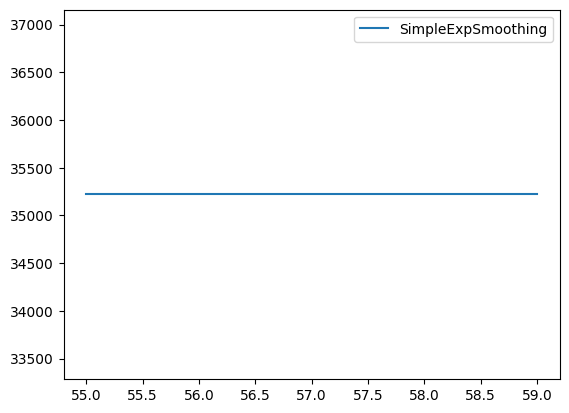

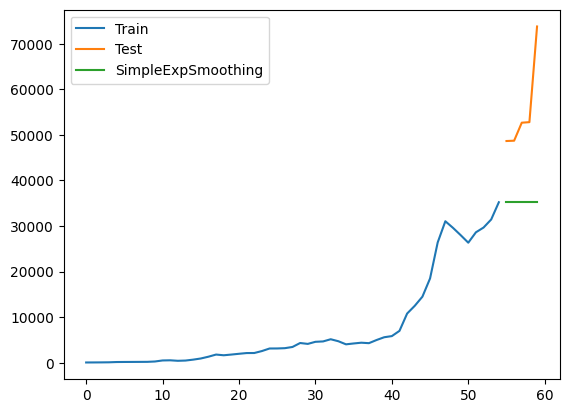

RMS Error 22193.344772701566


In [78]:
#######################  SimpleExpSmoothing  ########################
from statsmodels.tsa.api import SimpleExpSmoothing
alpha = 1 # 0 < alpha <= 1
fit1=SimpleExpSmoothing(y_train).fit(smoothing_level=alpha)
fcast1 = fit1.forecast(len(y_test))

plt.plot(y_train,label='Train')
plt.legend(loc='best')
plt.show()

plt.plot(y_test,label='Test')
plt.legend(loc='best')
plt.show()

plt.plot(fcast1,label="SimpleExpSmoothing")
plt.legend(loc='best')
plt.show()

plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.plot(fcast1,label="SimpleExpSmoothing")
plt.legend(loc='best')
plt.show()

rms=sqrt(mean_squared_error(y_test, fcast1))
print(f'RMS Error {rms}')

In [79]:
alpha = list(np.arange(0, 1.1, 0.1))
for i in alpha:
    print(f'Alpha:{i} RMS:{sqrt(mean_squared_error(y_test,SimpleExpSmoothing(y_train).fit(smoothing_level=i).forecast(len(y_test))))}')

Alpha:0.0 RMS:56053.524978028814
Alpha:0.1 RMS:35149.73341359214
Alpha:0.2 RMS:28897.013028529524
Alpha:0.30000000000000004 RMS:26475.205098120867
Alpha:0.4 RMS:25297.71781543846
Alpha:0.5 RMS:24534.164166498827
Alpha:0.6000000000000001 RMS:23928.799188182486
Alpha:0.7000000000000001 RMS:23409.914762992972
Alpha:0.8 RMS:22955.66443312629
Alpha:0.9 RMS:22553.709537690003
Alpha:1.0 RMS:22193.344772701566


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

### Holt's Method  ###

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


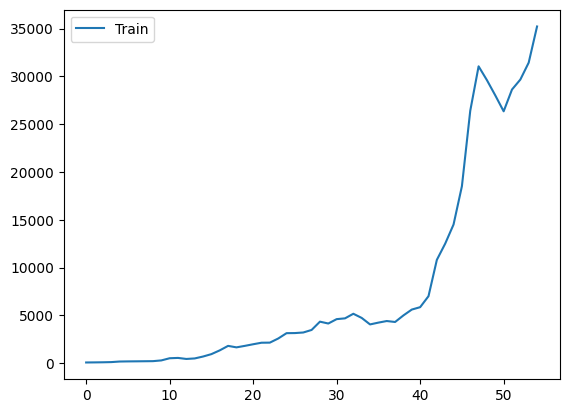

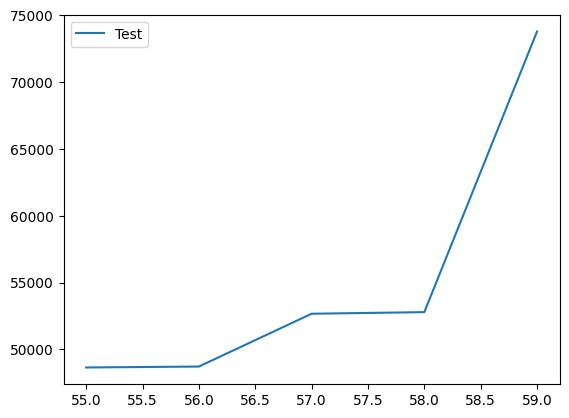

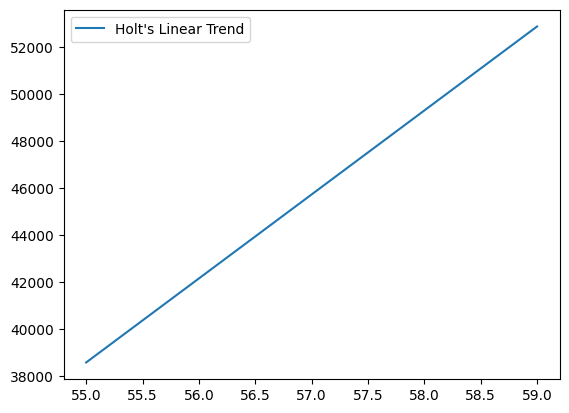

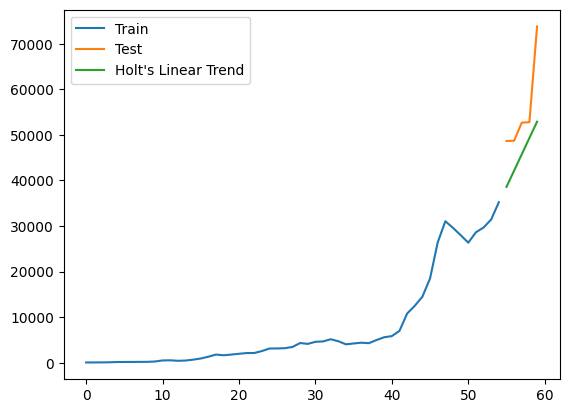

RMS: 11321.41680183803


In [86]:
############ Linear Trend ############
alpha = 0.9
beta = 0.99
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import Holt

fit1=Holt(y_train).fit(smoothing_level=alpha,smoothing_trend=beta)
fcast1 = fit1.forecast(len(y_test))

plt.plot(y_train,label='Train')
plt.legend(loc='best')
plt.show()

plt.plot(y_test,label='Test')
plt.legend(loc='best')
plt.show()

plt.plot(fcast1,label="Holt's Linear Trend")
plt.legend(loc='best')
plt.show()

plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.plot(fcast1,label="Holt's Linear Trend")
plt.legend(loc='best')
plt.show()

rms=sqrt(mean_squared_error(y_test, fcast1))
print(f'RMS: {rms}') #102.13849221483085

In [84]:
alpha = list(np.arange(0, 1.1, 0.1))
beta = 0.01

for i in alpha:
    print(f'Alpha:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train).fit(smoothing_level=i,smoothing_trend=beta).forecast(len(y_test))))}')

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Alpha:0.0 RMS:55565.91415663473
Alpha:0.1 RMS:33533.5897497542
Alpha:0.2 RMS:27305.640172852938
Alpha:0.30000000000000004 RMS:25029.911583177058
Alpha:0.4 RMS:23986.344036362625
Alpha:0.5 RMS:23320.02850829924
Alpha:0.6000000000000001 RMS:22780.788751770844
Alpha:0.7000000000000001 RMS:22307.178031831558
Alpha:0.8 RMS:21885.182951793897
Alpha:0.9 RMS:21507.193329937574
Alpha:1.0 RMS:21165.147247609308


In [85]:
beta = list(np.arange(0, 1, 0.01))
alpha = 1

for i in beta:
    print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train).fit(smoothing_level=alpha,smoothing_trend=i).forecast(len(y_test))))}')

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.0 RMS:22166.0871501941
Beta:0.01 RMS:21165.147247609308
Beta:0.02 RMS:20352.606102909103
Beta:0.03 RMS:19687.541276976346
Beta:0.04 RMS:19139.74688684178
Beta:0.05 RMS:18686.464419064538
Beta:0.06 RMS:18310.175462602696
Beta:0.07 RMS:17997.107038874812
Beta:0.08 RMS:17736.214491562856
Beta:0.09 RMS:17518.484270909332
Beta:0.1 RMS:17336.451106995723
Beta:0.11 RMS:17183.859101804075
Beta:0.12 RMS:17055.41973096255
Beta:0.13 RMS:16946.635417515474
Beta:0.14 RMS:16853.667788015115
Beta:0.15 RMS:16773.236677054396
Beta:0.16 RMS:16702.540573019804
Beta:0.17 RMS:16639.192273631157
Beta:0.18 RMS:16581.16556408519
Beta:0.19 RMS:16526.75008916349
Beta:0.2 RMS:16474.512493514172
Beta:0.21 RMS:16423.262504381797


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.22 RMS:16372.023030000211
Beta:0.23 RMS:16320.003612291219
Beta:0.24 RMS:16266.576749415839
Beta:0.25 RMS:16211.256722039769
Beta:0.26 RMS:16153.680636817513
Beta:0.27 RMS:16093.59145480119
Beta:0.28 RMS:16030.822810015143
Beta:0.29 RMS:15965.285450102068
Beta:0.3 RMS:15896.955150551537
Beta:0.31 RMS:15825.861969055712
Beta:0.32 RMS:15752.080718609066


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

...

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.65 RMS:12862.73873807421
Beta:0.66 RMS:12784.433271845981
Beta:0.67 RMS:12707.141958599865
Beta:0.68 RMS:12630.845502638638
Beta:0.6900000000000001 RMS:12555.521593328745
Beta:0.7000000000000001 RMS:12481.145384016401
Beta:0.71 RMS:12407.68995075487
Beta:0.72 RMS:12335.126729711039
Beta:0.73 RMS:12263.42593238051
Beta:0.74 RMS:12192.556937975789
Beta:0.75 RMS:12122.488662564172
Beta:0.76 RMS:12053.189904722947
Beta:0.77 RMS:11984.629667651216
Beta:0.78 RMS:11916.777457832284
Beta:0.79 RMS:11849.603560479502
Beta:0.8 RMS:11783.079292123039
Beta:0.81 RMS:11717.177230806823
Beta:0.8200000000000001 RMS:11651.871424464876
Beta:0.8300000000000001 RMS:11587.137578135298
Beta:0.84 RMS:11522.953220749288
Beta:0.85 RMS:11459.29785230263
Beta:0.86 RMS:11396.153072278405
Beta:0.87 RMS:11333.502690243002


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.88 RMS:11271.332819583717
Beta:0.89 RMS:11209.631955394665
Beta:0.9 RMS:11148.39103755038
Beta:0.91 RMS:11087.603500031899
Beta:0.92 RMS:11027.265307590182
Beta:0.93 RMS:10967.374980845703
Beta:0.9400000000000001 RMS:10907.933610931468
Beta:0.9500000000000001 RMS:10848.944864790268
Beta:0.96 RMS:10790.414982235268
Beta:0.97 RMS:10732.352765876749
Beta:0.98 RMS:10674.76956500728
Beta:0.99 RMS:10617.679254523004


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


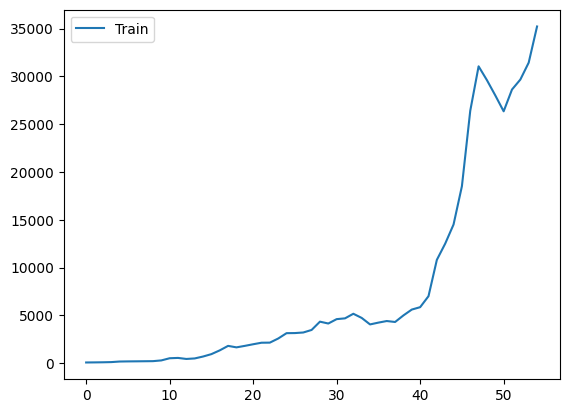

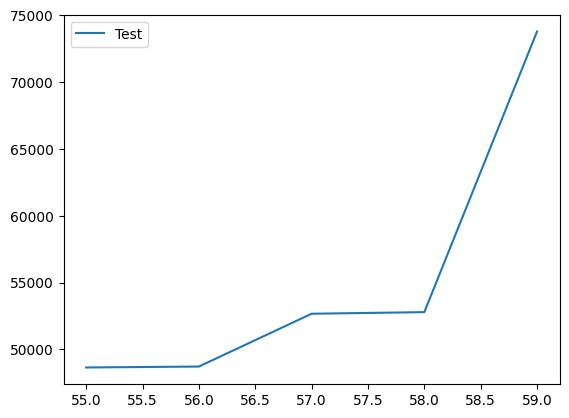

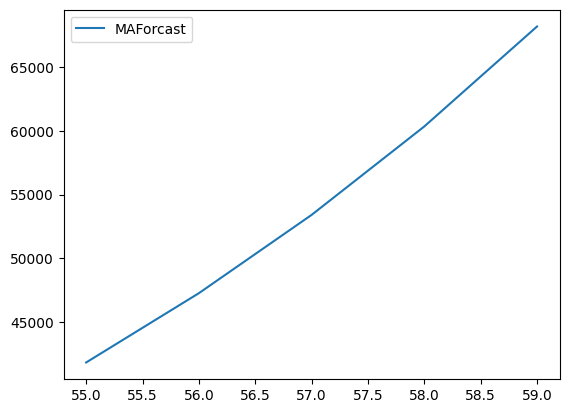

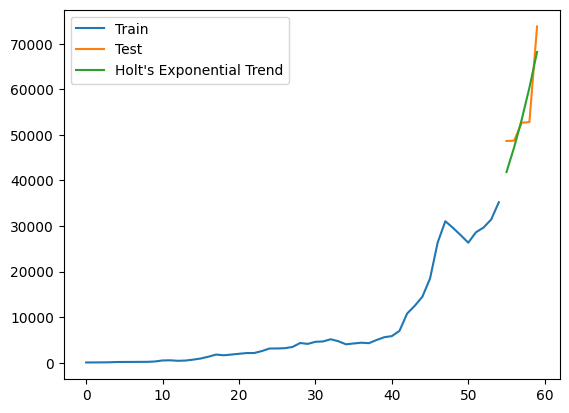

5245.475298454827


In [90]:
############ Exponential Trend ############
alpha = 0.5
beta = 0.01
fit1=Holt(y_train,exponential=True).fit(smoothing_level=alpha,smoothing_trend=beta)
fcast1 = fit1.forecast(len(y_test))

plt.plot(y_train,label='Train')
plt.legend(loc='best')
plt.show()
plt.plot(y_test,label='Test')
plt.legend(loc='best')
plt.show()

plt.plot(fcast1,label="MAForcast")
plt.legend(loc='best')
plt.show()

plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.plot(fcast1,label="Holt's Exponential Trend")
plt.legend(loc='best')
plt.show()

rms=sqrt(mean_squared_error(y_test, fcast1))
print(rms) 

In [88]:
alpha = list(np.arange(0, 1.1, 0.1))
beta = 0.01

for i in alpha:
    print(f'Alpha:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True).fit(smoothing_level=i,smoothing_trend=beta).forecast(len(y_test))))}')

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Alpha:0.0 RMS:42370.399737617154
Alpha:0.1 RMS:24043.938362313827
Alpha:0.2 RMS:11015.683845252846
Alpha:0.30000000000000004 RMS:7054.825250924923
Alpha:0.4 RMS:5335.625595374547
Alpha:0.5 RMS:5245.475298454827
Alpha:0.6000000000000001 RMS:5587.7435888892205
Alpha:0.7000000000000001 RMS:5859.329679351886
Alpha:0.8 RMS:6009.097521759397
Alpha:0.9 RMS:6071.276040159482
Alpha:1.0 RMS:6075.546370023564


In [89]:
beta = list(np.arange(0, 1, 0.01))
alpha = 1

for i in beta:
    print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True).fit(smoothing_level=alpha,smoothing_trend=i).forecast(len(y_test))))}')

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.0 RMS:5957.290822202858
Beta:0.01 RMS:6075.546370023564
Beta:0.02 RMS:6424.171446448423
Beta:0.03 RMS:6895.5831970421905
Beta:0.04 RMS:7392.156934443496
Beta:0.05 RMS:7853.817799808951
Beta:0.06 RMS:8258.913985112937
Beta:0.07 RMS:8608.96990027233
Beta:0.08 RMS:8915.32728270919
Beta:0.09 RMS:9191.294962718499
Beta:0.1 RMS:9448.45720971454
Beta:0.11 RMS:9695.388457860241
Beta:0.12 RMS:9937.57740899273
Beta:0.13 RMS:10177.87444597131


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.14 RMS:10417.103458932106
Beta:0.15 RMS:10654.664992603157
Beta:0.16 RMS:10889.056847459042
Beta:0.17 RMS:11118.288966180684
Beta:0.18 RMS:11340.194123609273
Beta:0.19 RMS:11552.646963153004
Beta:0.2 RMS:11753.707814960537
Beta:0.21 RMS:11941.707936472814
Beta:0.22 RMS:12115.29120474028
Beta:0.23 RMS:12273.424916274407
Beta:0.24 RMS:12415.389815683116
Beta:0.25 RMS:12540.757108067985
Beta:0.26 RMS:12649.358169655274
Beta:0.27 RMS:12741.25100701859
Beta:0.28 RMS:12816.686215852216
Beta:0.29 RMS:12876.07421216626
Beta:0.3 RMS:12919.954796602247
Beta:0.31 RMS:12948.969610628928
Beta:0.32 RMS:12963.837701723167
Beta:0.33 RMS:12965.334191515294


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

...

C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.71 RMS:9475.529331345138
Beta:0.72 RMS:9380.934364714509
Beta:0.73 RMS:9287.60424900792
Beta:0.74 RMS:9195.514993457517
Beta:0.75 RMS:9104.64028560217
Beta:0.76 RMS:9014.952322246518
Beta:0.77 RMS:8926.422575501329
Beta:0.78 RMS:8839.022494943856
Beta:0.79 RMS:8752.72414712887
Beta:0.8 RMS:8667.500793838324
Beta:0.81 RMS:8583.327410583894
Beta:0.8200000000000001 RMS:8500.18114697541
Beta:0.8300000000000001 RMS:8418.041730640825
Beta:0.84 RMS:8336.891816433312
Beta:0.85 RMS:8256.717282692249
Beta:0.86 RMS:8177.5074763361745
Beta:0.87 RMS:8099.255408565593
Beta:0.88 RMS:8021.957902938898
Beta:0.89 RMS:7945.615697562656
Beta:0.9 RMS:7870.233503109295
Beta:0.91 RMS:7795.820018343277
Beta:0.92 RMS:7722.387904807641
Beta:0.93 RMS:7649.953722294383


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this

Beta:0.9400000000000001 RMS:7578.537826705096
Beta:0.9500000000000001 RMS:7508.164231901232
Beta:0.96 RMS:7438.860437152583
Beta:0.97 RMS:7370.657221824264
Beta:0.98 RMS:7303.588408997513
Beta:0.99 RMS:7237.69059980735


C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
C:\Users\R\anaconda3\lib\site-packages\pandas\util\_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


C:\Users\R\AppData\Local\Temp\ipykernel_8980\2744016505.py:4: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit3=Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=phi)
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


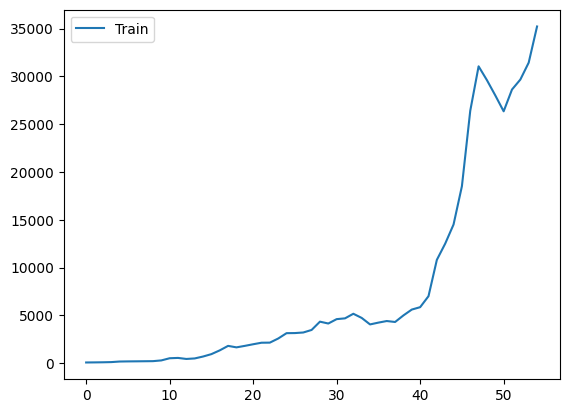

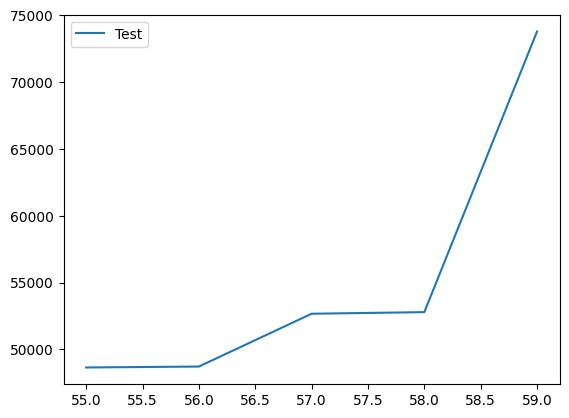

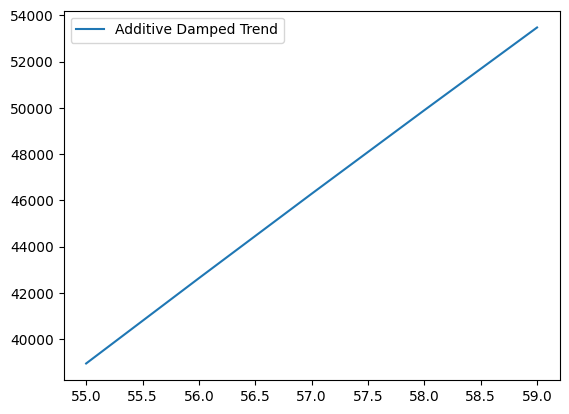

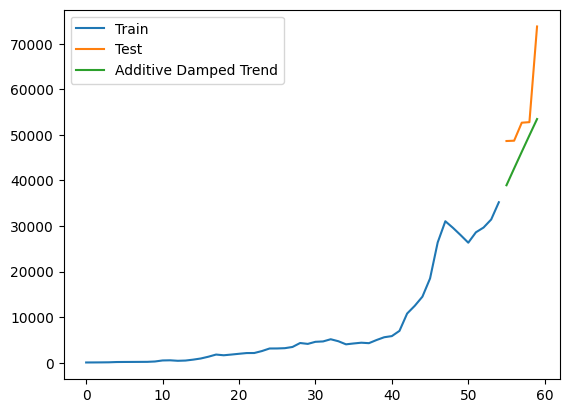

10889.922659875676


In [95]:
############ Additive Damped Trend ############
alpha = 1
phi = 0.99
fit3=Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=phi)
fcast3 = fit3.forecast(len(y_test))

plt.plot(y_train,label='Train')
plt.legend(loc='best')
plt.show()
plt.plot(y_test,label='Test')
plt.legend(loc='best')
plt.show()
plt.plot(fcast3,label="Additive Damped Trend")
plt.legend(loc='best')
plt.show()

plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.plot(fcast3,label="Additive Damped Trend")
plt.legend(loc='best')
plt.show()

rms=sqrt(mean_squared_error(y_test, fcast3))
print(rms) #84.22578787424938

In [92]:
alpha = list(np.arange(0, 1.1, 0.1))
phi = 0.01

for i in alpha:
    print(f'Alpha:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=i,smoothing_slope=phi).forecast(len(y_test))))}')

C:\Users\R\AppData\Local\Temp\ipykernel_8980\557057897.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Alpha:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=i,smoothing_slope=phi).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\557057897.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Alpha:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=i,smoothing_slope=phi).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_

Alpha:0.0 RMS:55686.23918390965
Alpha:0.1 RMS:33709.15142592778
Alpha:0.2 RMS:27474.093955912056
Alpha:0.30000000000000004 RMS:25188.824333206445
Alpha:0.4 RMS:24136.67042442983
Alpha:0.5 RMS:23463.26716703937
Alpha:0.6000000000000001 RMS:22918.38614612461
Alpha:0.7000000000000001 RMS:22440.321266815896
Alpha:0.8 RMS:22014.78217355031
Alpha:0.9 RMS:21573.6508728567
Alpha:1.0 RMS:21289.543309180353


In [94]:
phi = list(np.arange(0, 1, 0.01))
alpha = 1

for i in phi:
    print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')

C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,H

Beta:0.0 RMS:22178.059415608266
Beta:0.01 RMS:21289.543309180353
Beta:0.02 RMS:20557.816514449456
Beta:0.03 RMS:19951.077396553494
Beta:0.04 RMS:19445.312460340956
Beta:0.05 RMS:19022.019339804952
Beta:0.06 RMS:18666.65267902629
Beta:0.07 RMS:18367.55837207691
Beta:0.08 RMS:18115.237639855786


C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykerne

Beta:0.09 RMS:17901.8340290368
Beta:0.1 RMS:17720.771341518805
Beta:0.11 RMS:17566.49406957053
Beta:0.12 RMS:17434.277778588355
Beta:0.13 RMS:17137.859998846026
Beta:0.14 RMS:17041.36214815172
Beta:0.15 RMS:17132.466966736618
Beta:0.16 RMS:17053.550260655844
Beta:0.17 RMS:17590.947563242935
Beta:0.18 RMS:16914.671818811195


C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: Future

...

C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykerne

Beta:0.75 RMS:12379.705199000546
Beta:0.76 RMS:12311.230553568628
Beta:0.77 RMS:12243.469994454885
Beta:0.78 RMS:12176.394321239757
Beta:0.79 RMS:12109.975116039335
Beta:0.8 RMS:12044.184974071586
Beta:0.81 RMS:11978.99771406157
Beta:0.8200000000000001 RMS:11914.388568979315
Beta:0.8300000000000001 RMS:11850.334357686885
Beta:0.84 RMS:11786.813638145275
Beta:0.85 RMS:11723.80684289723
Beta:0.86 RMS:11661.296397599765
Beta:0.87 RMS:11599.266823430735
Beta:0.88 RMS:11537.704824237138
Beta:0.89 RMS:11476.599359329955


C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykerne

Beta:0.9 RMS:11415.941702861172
Beta:0.91 RMS:11355.725490743467
Beta:0.92 RMS:11295.946756092566
Beta:0.93 RMS:11236.603954186134
Beta:0.9400000000000001 RMS:11177.697977942074
Beta:0.9500000000000001 RMS:15414.812071499475
Beta:0.96 RMS:11061.212296873733
Beta:0.97 RMS:11003.646592791734
Beta:0.98 RMS:10946.545696525156
Beta:0.99 RMS:10889.922659875676


C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\469566012.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykerne

C:\Users\R\AppData\Local\Temp\ipykernel_8980\2050091755.py:4: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit3=Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=phi)
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


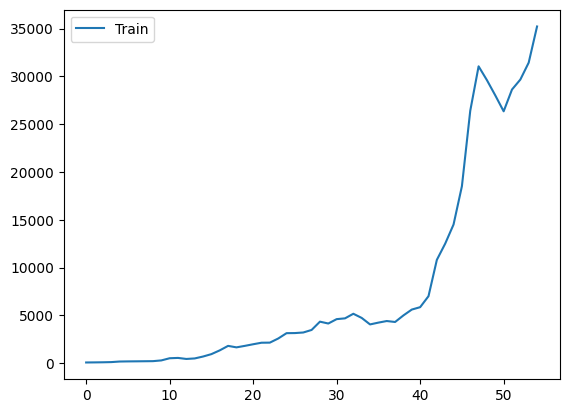

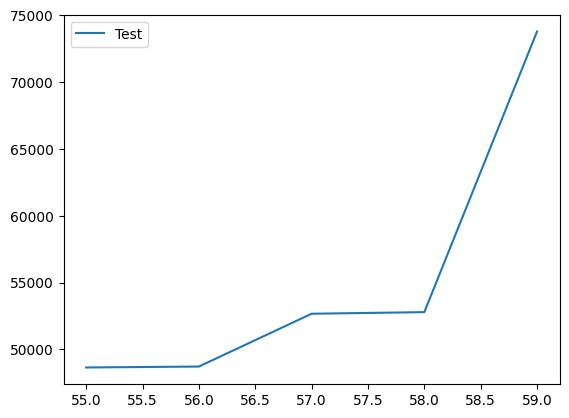

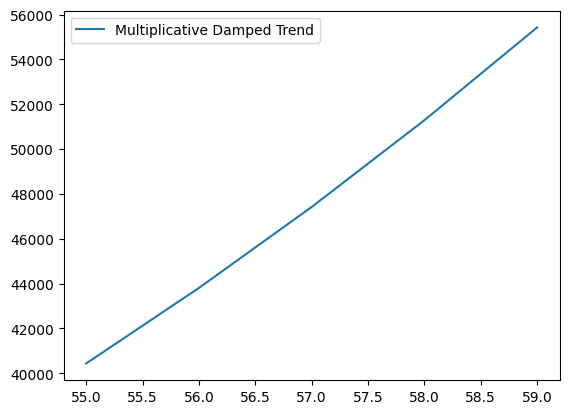

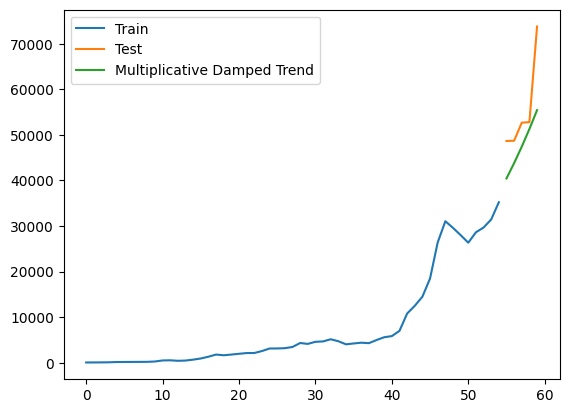

9577.833375467335


In [114]:
############ Multiplicative Damped Trend ############
alpha = 0.2
phi = 0.01
fit3=Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=phi)
fcast3 = fit3.forecast(len(y_test))

plt.plot(y_train,label='Train')
plt.legend(loc='best')
plt.show()
plt.plot(y_test,label='Test')
plt.legend(loc='best')
plt.show()
plt.plot(fcast3,label="Multiplicative Damped Trend")
plt.legend(loc='best')
plt.show()

plt.plot(y_train,label='Train')
plt.plot(y_test,label='Test')
plt.plot(fcast3,label="Multiplicative Damped Trend")
plt.legend(loc='best')
plt.show()

rms=sqrt(mean_squared_error(y_test, fcast3))
print(rms) # 82.70267105367338

In [100]:
alpha = list(np.arange(0, 1.1, 0.1))
phi = 0.01
MulDamped = {}
for i in alpha:
    #print(f'Alpha:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=i,smoothing_slope=phi).forecast(len(y_test))))}')
    MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=i,smoothing_slope=phi).forecast(len(y_test))))

C:\Users\R\AppData\Local\Temp\ipykernel_8980\2825315401.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=i,smoothing_slope=phi).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\2825315401.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=i,smoothing_slope=phi).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\T

In [106]:
print(MulDamped)

{0.0: 33012.247661351896, 0.1: 10440.849384009318, 0.2: 9577.833375467335, 0.30000000000000004: 10049.616456558872, 0.4: 14243.875840565792, 0.5: 11555.119349959466, 0.6000000000000001: 11839.52820625932, 0.7000000000000001: 11894.332712501824, 0.8: 11823.638423029348, 0.9: 11688.083274879611, 1.0: 11516.13954563421}


In [110]:
print(sorted(MulDamped.items(), key = lambda x:x[1]))

[(0.2, 9577.833375467335), (0.30000000000000004, 10049.616456558872), (0.1, 10440.849384009318), (1.0, 11516.13954563421), (0.5, 11555.119349959466), (0.9, 11688.083274879611), (0.8, 11823.638423029348), (0.6000000000000001, 11839.52820625932), (0.7000000000000001, 11894.332712501824), (0.4, 14243.875840565792), (0.0, 33012.247661351896)]


In [111]:
phi = list(np.arange(0, 1, 0.01))
alpha = 1
MulDamped = {}
for i in phi:
    #print(f'Beta:{i} RMS:{sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))}')
        MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))

C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Loc

C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Loc

C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Loc

C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Loc

C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Local\Temp\ipykernel_8980\1240693139.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  MulDamped[i] = sqrt(mean_squared_error(y_test,Holt(y_train,exponential=True,damped_trend=True).fit(smoothing_level=alpha,smoothing_slope=i).forecast(len(y_test))))
C:\Users\R\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\R\AppData\Loc

In [112]:
print(sorted(MulDamped.items(),key = lambda x:x[1]))

[(0.99, 7602.24657073995), (0.98, 7670.327005248493), (0.97, 7739.435288963844), (0.96, 7809.537863223066), (0.9400000000000001, 7952.606799611598), (0.93, 8025.521746758885), (0.92, 8099.328465928636), (0.91, 8174.010032068408), (0.9, 8249.553220572878), (0.89, 8325.948566560945), (0.88, 8403.190393139734), (0.87, 8481.276807115497), (0.86, 8560.209660586694), (0.85, 8639.994476829299), (0.84, 8720.640338857726), (0.8300000000000001, 8802.159739026023), (0.8200000000000001, 8884.568388016072), (0.81, 8967.88498155385), (0.8, 9052.130923196502), (0.79, 9137.330001546889), (0.78, 9223.508020281606), (0.77, 9310.692379421678), (0.76, 9398.911606337291), (0.75, 9488.19483505966), (0.74, 9578.571232576684), (0.73, 9670.069370917023), (0.71, 9856.538028258008), (0.7000000000000001, 9951.556286791654), (0.6900000000000001, 10047.790115985366), (0.68, 10145.253735145916), (0.67, 10243.955818968529), (0.66, 10343.898473542262), (0.65, 10445.076156861778), (0.64, 10547.47454529312), (0.63, 1065